
* Notes:
    * Data is uploaded from hdf5 file -> No need to use Tensorflow.
* Environment: robotic (env_robotic.yml)


In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..") # allows importing modules within this repository in a jupyter notebook.

import os
...

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset, WeightedRandomSampler
from torchvision import transforms
import torchvision.transforms.functional as TF
from torch.optim import Adam, SGD
from sentence_transformers import SentenceTransformer

import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import numpy as np
import math

from simulation.miniarm_env import MiniArmEnv
from simulation.oracle import Oracle, collect_demos
from preprocessing.preprocessing import get_settings
import pybullet as p


# torch.set_num_threads(6)
print(f"threads set to: {torch.get_num_threads()}")

threads set to: 12


pybullet build time: Nov 28 2023 23:45:17


# Data preparation


##### Data preprocessing pipeline
1. Load dataset
2. Discretize action space
3. Resize images
4. Embedding language instruction
5. Create dataloaders.

In [ ]:
from preprocessing.preprocessing import *

cfg = "cfg.json"
batch_size=32
N_BINS=32
settings = get_settings(settings=
                                              str(Path.cwd().parent / f"{cfg}"))

data_name_lst = settings["data_name_lst"] # characteristics: Franka, Single Arm, EEF Position.
output_name = settings["output_name"]
path_data = settings["path_data"]

############## open data
data, metadata = open_combined_dataset(path_data, output_name)
############## discretize data
data_discretized, action_percentiles = apply_discretization(data, metadata, N_BINS)
############## filter data
keys_to_keep = {
        "stanford_hydra_dataset_converted_externally_to_rlds": ["actions", "image", "language_instruction","episode_idx", "dataset_name"],
        "taco_play": ["rel_actions_world", "rgb_static", "natural_language_instruction", "episode_idx", "dataset_name"],
    }
# renaming_keys = {
#     "taco_play": [("rgb_static", "image"), ("rel_actions_world", "actions"), ("natural_language_instruction","language_instruction")],  # so both datasets share the key "image"
# }

renaming_keys = {
    "taco_play": [["rgb_static", "image"], ["rel_actions_world", "actions"], ["natural_language_instruction","language_instruction"]],  # so both datasets share the key "image"
}
print(data_discretized[10000].keys())
data_filtered = filter_keys(data_discretized, keys_to_keep, renaming_keys)
print(data_filtered[10000].keys())

############## resize images
# print(data_filtered[0]['image'].shape)
image_resizing(data_filtered)
# print(data_filtered[0]['image'].shape)

############## embedding language
data_filtered, lang_dim, text_model = add_language_embeddings(data_filtered)

############## Build dataloaders.
# get training and validation subsets. Force episodes to appear in train or val, but not both.
train_set, val_set = split_by_episode(data_filtered, val_frac=0.1, seed=42)

train_weights = make_weights(train_set, metadata)
val_weights   = make_weights(val_set, metadata)

train_sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)
train_loader  = DataLoader(
train_set,
sampler=train_sampler,
batch_size=batch_size,
num_workers=2,
persistent_workers=True,
worker_init_fn=worker_init_fn,
)

# no weighted sampling needed for validation. Just shuffle=False, full pass
val_loader = DataLoader(
val_set,
batch_size=batch_size,
shuffle=False,
num_workers=2,
persistent_workers=True,
worker_init_fn=worker_init_fn,
)


'''
All compile in:
train_loader, val_loader, lang_dim = get_dataloaders(cfg="cfg.json", n_bins=N_BINS, keys_to_keep=keys_to_keep, renaming_keys=renaming_keys, batch_size=batch_size)
'''


n_episodes: 16
n_episodes: 16
stanford_hydra_dataset_converted_externally_to_rlds
actions: shape=(9761, 6)
p1=[-0.01895591 -0.02405627 -0.02057381 -0.12112904 -0.16186282 -0.16376511]
p99=[0.02197458 0.02150433 0.02401781 0.12091041 0.11146203 0.16157938]
discretized_range=[0, 31]


taco_play
actions: shape=(1056, 6)
p1=[ 0.14739171 -0.41538738  0.19777607 -3.13861867 -0.53569646 -1.53636925]
p99=[0.49058009 0.62614233 0.55302485 3.13905847 0.12491795 1.73633049]
discretized_range=[0, 31]


taco_play
rel_actions_gripper: shape=(1056, 6)
p1=[-0.5188651  -1.04988477 -0.87823469 -0.84330282 -0.76780331 -1.98089754]
p99=[0.56948566 0.95734829 0.52781998 0.88023777 0.63672144 1.759892  ]
discretized_range=[0, 31]


taco_play
rel_actions_world: shape=(1056, 6)
p1=[-0.65884569 -1.04458029 -0.49734294 -0.74591375 -0.70896812 -1.77969494]
p99=[0.47416454 1.00982402 0.86957543 0.72206968 0.77220851 1.95908995]
discretized_range=[0, 31]


taco_play
terminate_episode: shape=(1056, 1)
p1=[0.]
p99=[

'\nAll compile in:\ntrain_loader, val_loader, lang_dim = get_dataloaders(cfg="cfg.json", n_bins=N_BINS, keys_to_keep=keys_to_keep, renaming_keys=renaming_keys, batch_size=batch_size)\n'

#### Tests

In [18]:
######################################## TEST: LOADING
print("=========================================================")
print("================= TEST: LOADING =========================")
print(metadata.keys())
print(metadata["stanford_hydra_dataset_converted_externally_to_rlds"]["total_samples"])
print(data[9760].keys())
print(data[9761].keys())
# np.stack([sample["dataset_name"] for sample in data])[9761:]

# print(data[10000]['actions'])
display(metadata["stanford_hydra_dataset_converted_externally_to_rlds"])
display(metadata["taco_play"])

######################################## TEST: DISCRETIZATION
print("=========================================================")
print("================= TEST: DISCRETIZATION =========================")
# test discretized and undiscretized produce inverse results
idx_element = 10000
bin_indices = torch.from_numpy(data_discretized[idx_element]['actions'].reshape(1, -1))

print(undiscretize(
    bin_indices=bin_indices,
    p1=action_percentiles[data_discretized[idx_element]['dataset_name']]['actions']['p1'],
    p99=action_percentiles[data_discretized[idx_element]['dataset_name']]['actions']['p99'],
    n_bins=32,
)
)
print(data[idx_element]['actions'])

# sanity checks, mirroring the original data structure
print(len(data_discretized))
print(data_discretized[9760].keys())
print(data_discretized[9761].keys())
# print(data[9760]["actions"], "->", data_discretized[9760]["actions"])
data_discretized[9761]['actions']


######################################## TEST: IMAGE RESIZING
print("=========================================================")
print("================= TEST: IMAGE RESIZING =========================")
def plot_images(data: list[dict], metadata: dict, data_name: str):
    # Dict: keys=(data_name, episode_idx), value=[indices in dataset of pair (data_name, episode_idx)].
    episode_to_indices = episode_to_ids(data)
    start = 0
    if data_name == "taco_play":
        start = metadata["stanford_hydra_dataset_converted_externally_to_rlds"]["total_samples"] + 1
    
    for idx in range(start, start+10):
        img = data[idx]["image"]
        print(f"Dataset: {data_name}\nEpisode: {data[idx]['episode_idx']}\nImage shape: {img.shape}\n\n")
        if img.shape[0] == 3:
            img = img.permute(1,2,0)
            
        plt.imshow(img)
        plt.show()

# plot_images(data_filtered, metadata, "stanford_hydra_dataset_converted_externally_to_rlds")

######################################## TEST: DATA LOADERS
print("=========================================================")
print("================= TEST: DATA LOADERS =========================")
def _check_data_leakage(data_filtered: list, train_set: Subset, val_set: Subset):
    train_eps = {(data_filtered[i]["dataset_name"], data_filtered[i]["episode_idx"]) for i in train_set.indices}
    val_eps   = {(data_filtered[i]["dataset_name"], data_filtered[i]["episode_idx"]) for i in val_set.indices}
    if len(train_eps & val_eps) == 0:
        print("No data leakage")
    else:
        print("Data leakage")
_check_data_leakage(data_filtered, train_set, val_set)

================= TEST: LOADING =========================
dict_keys(['stanford_hydra_dataset_converted_externally_to_rlds', 'taco_play'])
9761
dict_keys(['actions', 'image', 'language_instruction', 'episode_idx', 'dataset_name'])
dict_keys(['actions', 'rel_actions_gripper', 'rel_actions_world', 'terminate_episode', 'rgb_gripper', 'rgb_static', 'natural_language_instruction', 'episode_idx', 'dataset_name'])


{'actions_metadata': {'type': 'Tensor',
  'shape': [7],
  'dtype': "<dtype: 'float32'>",
  'description': "Documentation(desc='Robot action, consists of [3x EEF positional delta, 3x EEF orientation delta in euler angle, 1x close gripper].', value_range='')"},
 'image_keys': ['image'],
 'action_keys': ['actions'],
 'language_keys': ['language_instruction'],
 'total_samples': 9761}

{'actions_metadata': {'terminate_episode': {'type': 'Tensor',
   'shape': [],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='', value_range='')"},
  'rel_actions_world': {'type': 'Tensor',
   'shape': [7],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='relative actions for gripper pose in the robot base frame (first 6 dimensions are x, y, z, yaw, pitch, roll), last dimension is open_gripper (-1 is open gripper, 1 is close)', value_range='')"},
  'rel_actions_gripper': {'type': 'Tensor',
   'shape': [7],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='relative actions for gripper pose in the gripper camera frame (first 6 dimensions are x, y, z, yaw, pitch, roll), last dimension is open_gripper (-1 is open gripper, 1 is close)', value_range='')"},
  'actions': {'type': 'Tensor',
   'shape': [7],
   'dtype': "<dtype: 'float32'>",
   'description': "Documentation(desc='absolute desired values for gripper pose (fir

================= TEST: DISCRETIZATION =========================
tensor([[ 0.2814,  0.4797,  0.5364,  3.0410, -0.0712,  1.0716]])
[ 0.2848146   0.46722233  0.5354779   3.1059792  -0.07630603  1.0550355 ]
10817
dict_keys(['actions', 'image', 'language_instruction', 'episode_idx', 'dataset_name'])
dict_keys(['actions', 'rel_actions_gripper', 'rel_actions_world', 'terminate_episode', 'rgb_gripper', 'rgb_static', 'natural_language_instruction', 'episode_idx', 'dataset_name'])
================= TEST: IMAGE RESIZING =========================
================= TEST: DATA LOADERS =========================
No data leakage


# Model

* Input: Image
    * OxE datasets contain different image resolutions -> Images must be same resolution.
    * Use for both datasets the 3rd-person view only (image for Hydra, rgb_static for taco_play).
    * Dimensions ([height, width, RGB]):
        * Hydra -> (240,320,3)
        * taco_play (rgb_static) ->  (150, 200, 3)
    * Normalize images:
        * Feeding your conv2d patchify layer inputs that are all positive means the gradients on that layer's weights tend to move in a more correlated biased direction (since the input's mean isn't 0), which slows down and destabilizes early training.
        * Consistency across datasets:
            * Images might differ in brightness, contrast or camera/sensor characteristics. Normalization puts them in equal footing.
    * 
* Output: Action token

* 7 DoF of action space are discretized in 256 bins.

### Archictecture:

* PatchEmbedding():
* TransformerEncoderBlock():
* VisionTransformer():
* ActionHead():
* RoboticActionPrediction():

* Image encoder (follow Dosovitskiy et al 2021, arXiv ~ ViT paper):
    * Overall architecture: Images -> CNN: extract patches from CNN feature map → linear projection to (D) → +pos embed + [class] token → Transformer encoder → head
    * PatchEmbedding():
        * CNN ~ Patchify:
        * Transform 2D images into sequence of patches (suitable for Transformers which have no built-in notion of spatial structure).
    * TransformerEncoderBlock():
        * MSA(LN(x)) + residual:
            * First apply <b>LayerNorm</b> to the current sequence representation (x).
                * 2016 - Layer Normalization - Lei Ba, Kiros, Hinton (https://arxiv.org/pdf/1607.06450)
            * Then apply <b>multi-head self-attention (MSA)</b>
            * Then add back the original (x) via a skip/<b>residual</b> connection.
    * MLP(LN(x)) + residual: this is the feed-forward (MLP) sublayer that follows attention within each Transformer encoder layer, again in pre-normalization form. You apply LayerNorm, then the MLP block, then add a residual connection (skip connection) from the block input. The paper also specifies that this MLP has two layers with a GELU non-linearity.
    * MLP head at the end of the transformer to project image embedding onto language model input space (256 tokens).
    * Notes:
        * Self-attention itself is permutation-invariant — it has no idea that patch 5 is next to patch 6, or that patch 1 is top-left and patch 196 is bottom-right. Without positional information, shuffling all the patches would produce the identical output. So after patchifying, you add a learned (or fixed sinusoidal) positional embedding per patch position

* ActionPrediction:
    * One ActionHead per dataset. Thus, both datasets share the ViT backbone, but they differ in the ActionHead.
    * When using the trained model to make inference, the same ViT backbone is used regardless of the data, but only the ActionHead associated to the input data will be used.
        * Important: That means that ActionHead['simulated'] remains untrained by the end of the training procedure.

In [ ]:
# Example instantiation, ViT-Base config from Table 1 (12 layers, D=768, MLP=3072, 12 heads)


# forward pass
# batch = next(iter(train_loader))
# logits = model(batch["image"], dataset_name=batch["dataset_name"][0])  # (B, action_dim, 256)

Name: patch_embed 
Child: PatchEmbedding(
  (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
)
Name: dropout 
Child: Dropout(p=0.1, inplace=False)
Name: encoder_blocks 
Child: ModuleList(
  (0-2): 3 x TransformerEncoderBlock(
    (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
    )
    (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (mlp): Sequential(
      (0): Linear(in_features=192, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=512, out_features=192, bias=True)
      (4): Dropout(p=0.1, inplace=False)
    )
  )
)
Name: final_norm 
Child: LayerNorm((192,), eps=1e-05, elementwise_affine=True)
Name: lang_proj 
Child: Linear(in_features=384, out_features=192, bias=True)


# Plot model metrics

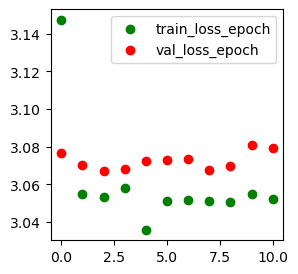

In [ ]:
with h5py.File(str(Path.cwd().parent) + '/data/metrics_epoch.pt', "r") as f:
    metrics_epoch = {key: f[key][()] for key in f}

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(3,3))

ax.scatter(np.arange(len(metrics_epoch['train_loss_epoch'])),metrics_epoch['train_loss_epoch'],label='train_loss_epoch',color='green')
ax.scatter(np.arange(len(metrics_epoch['val_loss_epoch'])),metrics_epoch['val_loss_epoch'],label='val_loss_epoch',color='red')

ax.legend()
plt.show()

# Simulated data

# Fine-Tuning using LoRA

In [11]:
from model.train import action_ce_loss, action_accuracy, get_model
from model.models import RoboticActionModel
from model.fine_tune import setup_lora_model, finetune_lora
from preprocessing.preprocessing import get_dataloaders_sim
from preprocessing.utils import get_settings

N_BINS=32
BATCH_SIZE=16
cfg = "cfg.json"
settings = get_settings(settings=str(Path.cwd().parent / f"{cfg}"))
keys_to_keep = settings["keys_to_keep"]
renaming_keys = settings["renaming_keys"]

sim_train_loader, sim_val_loader, lang_dim = get_dataloaders_sim(cfg=cfg,
    n_bins=N_BINS,
    keys_to_keep=keys_to_keep,
    renaming_keys=renaming_keys,
    batch_size=BATCH_SIZE)

# load the pretrained checkpoint (encoder + hydra/taco_play heads) first
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(str(Path.cwd().parent) + "/data/best_model.pt", map_location=device)
parameters = settings["model_parameters"]
parameters["lang_dim"] = lang_dim
model = get_model(parameters)
model.load_state_dict(checkpoint["model_state_dict"])


# freeze everything, inject LoRA into the encoder, unfreeze the new sim head
model = setup_lora_model(model, r=8, alpha=16, dropout=0.05, new_head_name="simulated")
num_epochs=4
model, lora_metrics = finetune_lora(
    model,
    sim_train_loader,
    sim_val_loader,
    device,
    dataset_name="simulated",
    num_epochs=num_epochs,
    lr=1e-3,
)

n_episodes: 5
1 unique instructions
Name: patch_embed 
Child: PatchEmbedding(
  (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
)
Name: dropout 
Child: Dropout(p=0.1, inplace=False)
Name: encoder_blocks 
Child: ModuleList(
  (0-2): 3 x TransformerEncoderBlock(
    (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
    )
    (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (mlp): Sequential(
      (0): Linear(in_features=192, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=512, out_features=192, bias=True)
      (4): Dropout(p=0.1, inplace=False)
    )
  )
)
Name: final_norm 
Child: LayerNorm((192,), eps=1e-05, elementwise_affine=True)
Name: lang_proj 
Child: Linear(in_features=384, out_features=192, bias=True)
trainable params: 19

# Rollout model.

* The pre-trained model on OxE data will be deployed for prediction using simulated (Pybullet) data.
* Simulated data contains: images and end_effecto position/orientation of a Franka arm robot trajectories.
* Simulated data:
    - rgb: camera data ~ images.
    - depth: ...
    - proprio: joint angle (rad): how much a joint is rotated. Internal configuration; velocity; ee_pos; ee_orn
    - ee_pos: end effector position in URDF frame of reference.
    - ee_orn: end effector orientation (quaternion) in URDF frame of reference.
    - actions: direction of adjustment of the end effector so it reaches the sphere. Taken as the current end effector position and the position of the sphere.

In [ ]:
@torch.no_grad()
def predict_sim_action(model, rgb_obs: np.ndarray, fixed_mean: torch.Tensor, fixed_std: torch.Tensor,
                        action_percentiles: dict, text_model_sim: SentenceTransformer, device,
                        dataset_name: str = "simulated", out_image_dim: int = 224, n_bins: int = 32) -> np.ndarray:
    """
    Runs one forward pass on a single simulated-environment RGB frame and
    returns a continuous action ready for env.step().

    fixed_mean/fixed_std: per-channel normalization stats computed ONCE from
        the sim training data (see previous message) -- NOT computed live per
        frame, since at rollout time we only have a single frame, not a whole
        episode to derive per-episode statistics from.
    action_percentiles: the p1/p99 dict computed when the sim training data
        was discretized -- needed to invert bin indices back to continuous values.
    """
    model.eval()

    # (H, W, 3) uint8 -> (3, H, W) float tensor in [0, 1]
    rgb_tensor = TF.to_tensor(rgb_obs)

    # resize + normalize with the FIXED stats (matches training-time preprocessing,
    # but using fixed rather than per-episode stats -- see prior discussion)
    transform = transforms.Compose([
        transforms.Resize((out_image_dim, out_image_dim), interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.Normalize(mean=fixed_mean, std=fixed_std),
    ])
    rgb_tensor = transform(rgb_tensor)             # (3, 224, 224)
    rgb_tensor = rgb_tensor.unsqueeze(0).to(device)  # (1, 3, 224, 224) -- add batch dim

    # language instruction
    language = text_model_sim.encode(["reach the green sphere"], convert_to_tensor=True,
                         normalize_embeddings=True).to(device)

    # forward pass
    logits = model(rgb_tensor, language, dataset_name=dataset_name)  # (1, action_dim, n_bins)
    bin_indices = logits.argmax(dim=-1)                       # (1, action_dim)
    
    print(f"predict_sim_action: {bin_indices}\t {bin_indices.dtype}")
    # undo discretization: bin index -> continuous value, using this dataset's p1/p99
    p1 = torch.tensor(action_percentiles[dataset_name]["actions"]["p1"], device=device, dtype=torch.float32)
    p99 = torch.tensor(action_percentiles[dataset_name]["actions"]["p99"], device=device, dtype=torch.float32)
    continuous_action = undiscretize(bin_indices, p1, p99, n_bins=n_bins)  # (1, action_dim)

    return continuous_action.squeeze(0).cpu().numpy()  # (action_dim,)

In [ ]:
# Rollout model on simulated environment.
# Generate a new environment.
# Use the model to predict the action based on rgb (image data)
# Check whether the ee_pos lands into success when the action is selected based on model.

# p.disconnect()
env = MiniArmEnv(max_steps=50, image_size=224)  
success, iteration, n_iterations = 0, 0, 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# fixed normalization stats, computed once from sim training data (see prior message)
sim_stats = torch.load(str(Path.cwd().parent) + "/data/sim_image_stats.pt", map_location=device)
fixed_mean = sim_stats["mean"]
fixed_std = sim_stats["std"]

while iteration < n_iterations:
    obs = env.reset()

    done = False
    while not done:
        action = predict_sim_action(
            model,
            obs["rgb"],
            fixed_mean,
            fixed_std,
            action_percentiles,
            text_model_sim,
            device,
            dataset_name="simulated",
        )

        obs, _, done, info = env.step(action)

    if info["success"]:
        success += 1

    print(f"iteration {iteration + 1}/{n_iterations} | success so far: {success}")
    iteration += 1

env.close()

startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Intel
GL_RENDERER=Mesa Intel(R) Graphics (MTL)
GL_VERSION=4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.4
GL_SHADING_LANGUAGE_VERSION=4.60
pthread_getconcurrency()=0
Version = 4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.4
Vendor = Intel
Renderer = Mesa Intel(R) Graphics (MTL)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
predict_sim_action: 

In [ ]:
print(f"Percentage of success: {(success / n_iterations) * 100:.2f}%")

Percentage of success: 20.00%
